# Sanity Check: Computing P from G Lesser and G Greater
The polarization should be just the correlation of G lesser and G greater. Since we've saved the data from Quatrex, let's try computing it manually to see if it matches the saved polarization data. Note that the convolution will expand the domain. The P Greater is the right side of the domain. The P Lesser is the left side of the domain.

I had to be careful with the prefactors, conjugates, negatives, and reversing the order of the arrays. But I got the np.fft.fft calculation to match exactly the saved P data.

In [1]:
# load data
import numpy as np
from quatrex.core.config import parse_config
from pathlib import Path

from scba_container.scba_container import SCBAContainer

simulation_dir = Path("./../../examples/w90/carbon-nanotube/gw")
output_dir = simulation_dir / "outputs"
output_file_prefix = output_dir / "visualize_scba"
archive_dir = simulation_dir / "archive" / "20260226_155038_energy2001_iter5_reduced"
archive_file_prefix = archive_dir / "visualize_scba"

# change these to switch between output and archive
data_files = 'archive'

if data_files == 'output':
    data_file_prefix = output_file_prefix
    config_dir = simulation_dir
elif data_files == 'archive':
    data_file_prefix = archive_file_prefix
    config_dir = archive_dir
else:
    raise ValueError(f"Invalid data_files value: {data_files}. Must be 'output' or 'archive'.")

config = parse_config(config_dir / "quatrex_config.toml")

max_idx = 43823  # total nnz entries - 1
sample_indices = np.load(f"{data_file_prefix}_sample_indices.npy")
num_samples = len(sample_indices)

SCBADataObj = SCBAContainer(
    max_iterations=config.scba.max_iterations,
    energy_window_min=config.electron.energy_window_min,
    energy_window_max=config.electron.energy_window_max,
    energy_window_num=config.electron.energy_window_num,
    num_samples=num_samples,
)

SCBADataObj.load_sample_indices(data_file_prefix)

for i in range(config.scba.max_iterations):
    SCBADataObj.load_g_data(data_file_prefix, iteration=i)
    SCBADataObj.load_p_data(data_file_prefix, iteration=i)
    SCBADataObj.load_w_data(data_file_prefix, iteration=i)
    SCBADataObj.load_sigma_data(data_file_prefix, iteration=i)

# === user parameters ===
iteration = 3
sample_idx = 86

assert (
    sample_idx <= num_samples
), f"sample_idx={sample_idx} exceeds num_samples={num_samples}"
nnz_index = SCBADataObj.sample_indices[sample_idx]

g_lesser = SCBADataObj.g_lesser[iteration, :, sample_idx]
g_greater = SCBADataObj.g_greater[iteration, :, sample_idx]
p_lesser = SCBADataObj.p_lesser[iteration, :, sample_idx]
p_greater = SCBADataObj.p_greater[iteration, :, sample_idx]

/scratch/yongli/document/github/quatrex/src/qttools/__init__.py:56: UserWarning: 'cupy' is unavailable or not working, defaulting to 'numpy'. (No module named 'cupy')
  warnings.warn(
/scratch/yongli/document/github/quatrex/src/quatrex/core/config.py:933: UserWarning: The CPU code will run sequentially which may impact performance.
  warnings.warn(


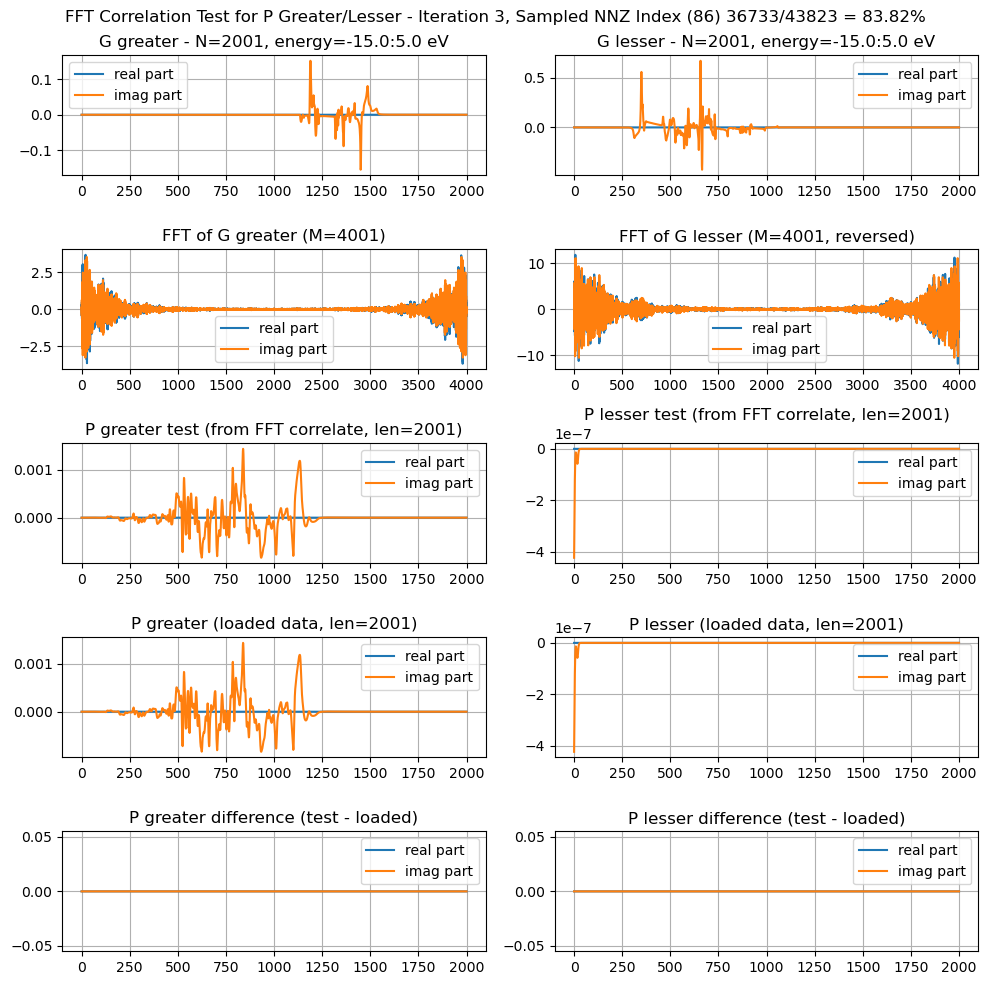

In [2]:
import numpy as np
from matplotlib import pyplot as plt


def fft_correlate(a, b):
    n = a.shape[0] + b.shape[0] - 1
    # n = a.shape[0]
    a_fft = np.fft.fft(a.T, n)
    b_fft = np.fft.fft(b[::-1].T, n)

    result = np.fft.ifft(a_fft * b_fft).T

    return result, a_fft, b_fft


prefactor = -1j / np.pi * np.abs(SCBADataObj.energies[1] - SCBADataObj.energies[0])

p_greater_test, F_g_greater, F_g_lesser = fft_correlate(g_greater, -1 * g_lesser.conj())
p_greater_test = prefactor * p_greater_test
p_lesser_test = -1 * p_greater_test[::-1].conj()

# take the second part of the correlation result to match the size
Ne = len(SCBADataObj.energies)
p_greater_test = p_greater_test[Ne - 1 :]
p_lesser_test = p_lesser_test[Ne - 1 :]

# discard the real part (keep only imag)
p_greater_test = 1j * np.imag(p_greater_test)
p_lesser_test = 1j * np.imag(p_lesser_test)


# region: === plotting ===
fig, axs = plt.subplots(5, 2, figsize=(10, 10))
axs[0, 0].set_title(
    f"G greater - N={len(SCBADataObj.energies)}, energy={SCBADataObj.energies[0]}:{SCBADataObj.energies[-1]} eV"
)
axs[0, 0].plot(np.real(g_greater), label="real part")
axs[0, 0].plot(np.imag(g_greater), label="imag part")
axs[0, 0].legend()
axs[0, 0].grid()

axs[0, 1].set_title(
    f"G lesser - N={len(SCBADataObj.energies)}, energy={SCBADataObj.energies[0]}:{SCBADataObj.energies[-1]} eV"
)
axs[0, 1].plot(np.real(g_lesser), label="real part")
axs[0, 1].plot(np.imag(g_lesser), label="imag part")
axs[0, 1].legend()
axs[0, 1].grid()

axs[1, 0].set_title(f"FFT of G greater (M={len(F_g_greater)})")
axs[1, 0].plot(np.real(F_g_greater), label="real part")
axs[1, 0].plot(np.imag(F_g_greater), label="imag part")
axs[1, 0].legend()
axs[1, 0].grid()

axs[1, 1].set_title(f"FFT of G lesser (M={len(F_g_lesser)}, reversed)")
axs[1, 1].plot(np.real(F_g_lesser), label="real part")
axs[1, 1].plot(np.imag(F_g_lesser), label="imag part")
axs[1, 1].legend()
axs[1, 1].grid()

axs[2, 0].set_title(f"P greater test (from FFT correlate, len={len(p_greater_test)})")
axs[2, 0].plot(np.real(p_greater_test), label="real part")
axs[2, 0].plot(np.imag(p_greater_test), label="imag part")
axs[2, 0].legend()
axs[2, 0].grid()

axs[2, 1].set_title(f"P lesser test (from FFT correlate, len={len(p_lesser_test)})")
axs[2, 1].plot(np.real(p_lesser_test), label="real part")
axs[2, 1].plot(np.imag(p_lesser_test), label="imag part")
axs[2, 1].legend()
axs[2, 1].grid()

axs[3, 0].set_title(f"P greater (loaded data, len={len(p_greater)})")
axs[3, 0].plot(np.real(p_greater), label="real part")
axs[3, 0].plot(np.imag(p_greater), label="imag part")
axs[3, 0].legend()
axs[3, 0].grid()

axs[3, 1].set_title(f"P lesser (loaded data, len={len(p_lesser)})")
axs[3, 1].plot(np.real(p_lesser), label="real part")
axs[3, 1].plot(np.imag(p_lesser), label="imag part")
axs[3, 1].legend()
axs[3, 1].grid()

axs[4, 0].set_title("P greater difference (test - loaded)")
axs[4, 0].plot(np.real(p_greater_test - p_greater), label="real part")
axs[4, 0].plot(np.imag(p_greater_test - p_greater), label="imag part")
axs[4, 0].legend()
axs[4, 0].grid()

axs[4, 1].set_title("P lesser difference (test - loaded)")
axs[4, 1].plot(np.real(p_lesser_test - p_lesser), label="real part")
axs[4, 1].plot(np.imag(p_lesser_test - p_lesser), label="imag part")
axs[4, 1].legend()
axs[4, 1].grid()

fig.suptitle(
    f"FFT Correlation Test for P Greater/Lesser - Iteration {iteration}, Sampled NNZ Index ({sample_idx}) {nnz_index}/{max_idx} = {nnz_index/max_idx:.2%}"
)

plt.tight_layout()
plt.show()
# endregion

In [3]:
print(f"p lesser all close: {np.allclose(p_lesser, p_lesser_test)}")
print(f"p greater all close: {np.allclose(p_greater, p_greater_test)}")

p lesser all close: True
p greater all close: True


# Adaptive energy grid - quadrature
Use the trapezoid rule and bisecting the segment to generate adaptive grid points. We'll use these grid points to compute a NUDFT later on.

If the bisecting rule tries to calculate an `f(x)` on an energy point where we don't have Green's function data, we'll use a 1-D linear inteprolation to find the value. This is a bit circular since the adaptive integration already uses a 1-D straight line method to calculate the trapezoidal area. But it seems to work.

The 1-D linear interpolation function (from scipy) is called 2x. Once for the real part and once for the imaginary part.

The error tolerances are arbitrary set to create an adaptive grid with a similar number of energy points as the original grid. The original grid has 1024 energy points.

In [4]:
# try adaptive energy grid with fewer points
def adaptive_integration_quadrature(
    func, x0, x1, tol=1e-6, integration_points=[], area_rule_func="simpsons_rule"
):
    """Perform adaptive integration using the trapezoidal rule."""

    def trapezoidal_rule(f, a, b):
        """Calculate the trapezoidal rule for a given function."""
        return (b - a) * (f(a) + f(b)) / 2

    def simpsons_rule(f, a, b):
        """Calculate Simpson's rule for a given function."""
        mid = (a + b) / 2
        return (b - a) / 6 * (f(a) + 4 * f(mid) + f(b))

    def recursive_integration(f, a, b, tol, points, area_rule_func):
        """Recursively apply the trapezoidal rule until the desired tolerance is met.
        Default area_rule_func is trapezoidal_rule, can be replaced with simpsons_rule.
        """
        mid = (a + b) / 2
        left_area = area_rule_func(f, a, mid)
        right_area = area_rule_func(f, mid, b)
        total_area = left_area + right_area
        if abs(total_area - area_rule_func(f, a, b)) < tol:
            points.append(mid)
            return total_area
        else:
            return recursive_integration(
                f, a, mid, tol / 2, points, area_rule_func=area_rule_func
            ) + recursive_integration(
                f, mid, b, tol / 2, points, area_rule_func=area_rule_func
            )

    if area_rule_func not in ["trapezoidal_rule", "simpsons_rule"]:
        raise ValueError(
            "area_rule_func must be either 'trapezoidal_rule' or 'simpsons_rule'"
        )
    area_rule_func = (
        trapezoidal_rule if area_rule_func == "trapezoidal_rule" else simpsons_rule
    )

    return recursive_integration(
        func, x0, x1, tol, integration_points, area_rule_func=area_rule_func
    )


def interpolation_of_g_greater_function(energy):
    """Interpolate (1D linear) the Green's function at a given energy."""

    # call it 2x to interpolate real and imag parts separately
    return np.interp(energy, SCBADataObj.energies, np.real(g_greater)) + 1j * np.interp(
        energy, SCBADataObj.energies, np.imag(g_greater)
    )


def interpolation_of_g_lesser_function(energy):
    """Interpolate (1D linear) the Green's function at a given energy."""

    # call it 2x to interpolate real and imag parts separately
    return np.interp(energy, SCBADataObj.energies, np.real(g_lesser)) + 1j * np.interp(
        energy, SCBADataObj.energies, np.imag(g_lesser)
    )


points = []
# tol_greater = 9e-5
tol_greater = 15e-6
integral = adaptive_integration_quadrature(
    interpolation_of_g_greater_function,
    x0=min(SCBADataObj.energies),
    x1=max(SCBADataObj.energies),
    tol=tol_greater,
    integration_points=points,
)
g_greater_points_quad = np.array(points)

points = []
tol_lesser = 110e-5
integral = adaptive_integration_quadrature(
    interpolation_of_g_lesser_function,
    x0=min(SCBADataObj.energies),
    x1=max(SCBADataObj.energies),
    tol=tol_lesser,
    integration_points=points,
)
g_lesser_points_quad = np.array(points)

print(f"Original number of energy points: {len(SCBADataObj.energies)}")
print(
    f"Adaptive integration selected {len(g_greater_points_quad)} points for g greater with tol={tol_greater:.1e}"
)
print(
    f"Adaptive integration selected {len(g_lesser_points_quad)} points for g lesser with tol={tol_lesser:.1e}"
)

Original number of energy points: 2001
Adaptive integration selected 1775 points for g greater with tol=1.5e-05
Adaptive integration selected 955 points for g lesser with tol=1.1e-03


# Gradient Monitor
Tue, Dec 23, 2025

Copying the gradient monitor from `/usr/scratch/mont-fort8/yongli/document/sandbox/adaptive_integration/adaptive_integration.ipynb`. I prefer this over the adaptive quadrature since you can directly specify the number of target points. From visual inspection, they give a similar clustering of adaptive points. The downside is that there is no guarantee on error bounds.


In [5]:
def monitor(x, type="gradient"):
    """Monitor function for adaptive integration."""
    if type == "gradient":
        # return the absolute gradient as the monitor function
        #   lose the real/imag parts here
        # return np.abs(np.diff(x, prepend=x[0])) # prepend to keep the same length
        return np.abs(np.gradient(x))
    elif type == "curvature":
        # return the absolute second derivative as the monitor function
        return np.abs(np.gradient(np.gradient(x)))
    else:
        raise ValueError("Unknown monitor type. Use 'gradient' or 'curvature'.")


def adaptive_points_from_monitor(x, monitor_type="gradient", N_target=100):
    """Generate adaptive points based on the monitor function."""
    M = monitor(x, type=monitor_type)
    C = np.cumsum(M)
    C = C / C[-1]  # normalize to [0, 1]

    targets = np.linspace(0, 1, N_target)
    # reverse the (x,y) to (y,x) for interpolation back to the original x-axis (energy grid)
    adaptive_points = np.interp(targets, C, SCBADataObj.energies)
    return adaptive_points, M, C


N_target = len(SCBADataObj.energies)
g_greater_points_monitor, M_greater, C_greater = adaptive_points_from_monitor(
    g_greater, monitor_type="gradient", N_target=N_target
)
g_lesser_points_monitor, M_lesser, C_lesser = adaptive_points_from_monitor(
    g_lesser, monitor_type="gradient", N_target=N_target
)

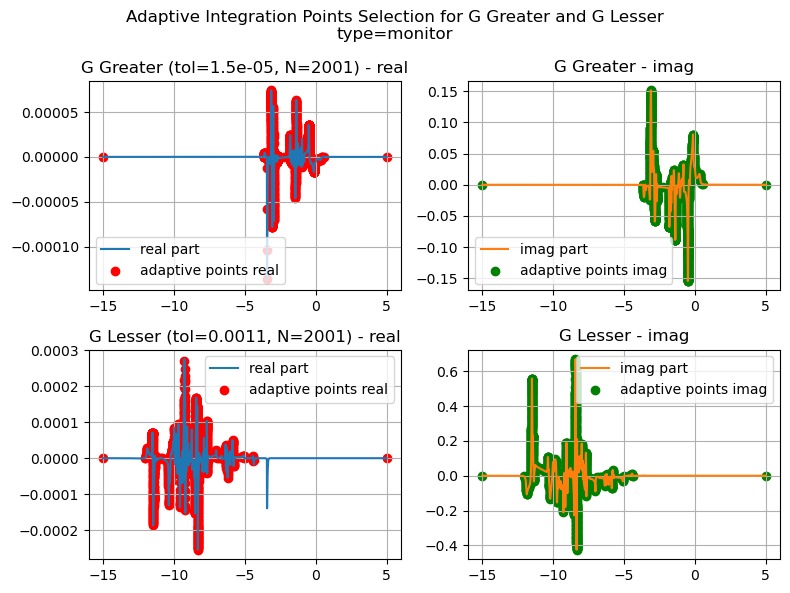

In [6]:
# === choose with adaptive points to us ===
adaptive_points_type = "monitor"  # 'quadrature' or 'monitor'

if adaptive_points_type == "quadrature":
    # adaptive quadrature
    g_greater_points = g_greater_points_quad
    g_lesser_points = g_lesser_points_quad
elif adaptive_points_type == "monitor":
    # monitor
    g_greater_points = g_greater_points_monitor
    g_lesser_points = g_lesser_points_monitor
else:
    raise ValueError("Unknown adaptive_points type. Use 'quadrature' or 'monitor'.")

from matplotlib import pyplot as plt

isPlotAdaptivePoints = True

if isPlotAdaptivePoints:
    fig, axes = plt.subplots(2, 2, figsize=(8, 6))

    axes[0, 0].set_title(
        f"G Greater (tol={tol_greater}, N={len(g_greater_points)}) - real"
    )
    axes[0, 0].plot(SCBADataObj.energies, np.real(g_greater), label="real part")
    axes[0, 0].scatter(
        g_greater_points,
        interpolation_of_g_greater_function(g_greater_points).real,
        color="red",
        label="adaptive points real",
    )
    axes[0, 0].legend()
    axes[0, 0].grid()

    axes[0, 1].set_title("G Greater - imag")
    axes[0, 1].plot(
        SCBADataObj.energies, np.imag(g_greater), color="tab:orange", label="imag part"
    )
    axes[0, 1].scatter(
        g_greater_points,
        interpolation_of_g_greater_function(g_greater_points).imag,
        color="green",
        label="adaptive points imag",
    )
    axes[0, 1].legend()
    axes[0, 1].grid()

    axes[1, 0].set_title(
        f"G Lesser (tol={tol_lesser}, N={len(g_lesser_points)}) - real"
    )
    axes[1, 0].plot(SCBADataObj.energies, np.real(g_lesser), label="real part")
    axes[1, 0].scatter(
        g_lesser_points,
        interpolation_of_g_lesser_function(g_lesser_points).real,
        color="red",
        label="adaptive points real",
    )
    axes[1, 0].legend()
    axes[1, 0].grid()

    axes[1, 1].set_title("G Lesser - imag")
    axes[1, 1].plot(
        SCBADataObj.energies, np.imag(g_lesser), color="tab:orange", label="imag part"
    )
    axes[1, 1].scatter(
        g_lesser_points,
        interpolation_of_g_lesser_function(g_lesser_points).imag,
        color="green",
        label="adaptive points imag",
    )
    axes[1, 1].legend()
    axes[1, 1].grid()

    fig.suptitle(
        f"Adaptive Integration Points Selection for G Greater and G Lesser\ntype={adaptive_points_type}"
    )

    plt.tight_layout()
    plt.show()

In [7]:
def dft(c, M=None):
    """Compute the Discrete Fourier Transform (DFT) of a 1D array c.
    Parameters:
        c (np.ndarray): Input 1D array of complex numbers.
        M (int, optional): Number of Fourier modes to compute. If None, uses the length of c.
            If M<len(c), c will be truncated. If M>len(c), c will be zero-padded.
    Returns:
        np.ndarray: DFT of the input array c with M modes.
    """
    N = c.shape[0]
    if M is None:
        M = N

    # liyongda (Fri, Dec 12, 2025)
    # this zero padding actually does nothing, since we only loop over c[n] in range(N)
    # and it's zeros, so it doesn't change the sum
    if M > N:
        # pad with zeros with on left side with 0 zeros, on right side with M-N zeros
        c = np.pad(c, (0, M - N))

    output = np.zeros(M, dtype=complex)
    for k in range(M):
        for n in range(N):
            output[k] += c[n] * np.exp(-2j * np.pi * k * n / M)
            # if (k==0):
            #     print(f"c[{n}], k={k}, n/M={n}/{M}={n/M}")

    # if M < N, truncate the output
    # else, return the whole length M output (so always return length M)
    return output[:M]


def nudft_weights(x, c, M=None, w=None):
    """Compute the Non-Uniform Discrete Fourier Transform (NUDFT) of a 1D array c, sampled at points x, with weights w.
    Parameters:
        x (np.ndarray): 1D array of sample points, normalized to [0, 1].
        c (np.ndarray): 1D array of complex numbers, function values at sample points x.
        M (int, optional): Number of Fourier modes to compute. If None, uses the length of x.
        w (np.ndarray, optional): 1D array of weights for each sample point. If None, all weights are set to 1.
    Returns:
        np.ndarray: NUDFT of the input array c with M modes.
    """

    assert (min(x) >= 0) and (max(x) <= 1), "x should be normalized to [0,1]"
    # if M<len(x), then it's the same as truncating the output
    #   ex. compute with M=len(x), but only take the first M output modes

    # number of fourier modes
    if M is None:
        M = x.shape[0]
    output = np.zeros(M, dtype=complex)

    # weights, if none provided, set to 1's
    if w is None:
        w = np.ones_like(x)

    # length of samples
    N = x.shape[0]

    # zero pad output if M>N
    if M > N:
        output = np.zeros(M, dtype=complex)

    # the direct implementation as in textbooks
    for k in range(M):
        for n in range(N):
            output[k] += w[n] * c[n] * np.exp(-2j * np.pi * k * x[n])

    return output[:M]


def nudft_weights_v2(x, c, M=None, w=None):
    """Compute the Non-Uniform Discrete Fourier Transform (NUDFT) of a 1D array c, sampled at points x, with weights w.
    Up to the user to squeeze x to [0, N/M] if needed.

    Parameters:
        x (np.ndarray): 1D array of sample points, normalized to [0, 1].
        c (np.ndarray): 1D array of complex numbers, function values at sample points x.
        M (int, optional): Number of Fourier modes to compute. If None, uses the length of x.
        w (np.ndarray, optional): 1D array of weights for each sample point. If None, all weights are set to 1.
    Returns:
        np.ndarray: NUDFT of the input array c with M modes.
    """
    assert (min(x) >= 0) and (max(x) <= 1), "x should be normalized to [0,1]"
    N = c.shape[0]

    # number of fourier modes
    if M is None:
        M = N

    # liyongda (Fri, Dec 12, 2025)
    # this zero padding actually does nothing, since we only loop over c[n] in range(N)
    # and it's zeros, so it doesn't change the sum
    if M > N:
        # zero pad
        c = np.pad(c, (0, M - N))

    output = np.zeros(M, dtype=complex)

    # weights, if none provided, set to 1's
    if w is None:
        w = np.ones_like(x)

    # the direct implementation as in textbooks
    for k in range(M):
        for n in range(N):
            output[k] += w[n] * c[n] * np.exp(-2j * np.pi * k * x[n])
            # if (k==0):
            #     print(f"c[{n}], x[{n}]={x[n]}")

    return output[:M]


def calculate_voronoi_weights(x, type="true"):
    """Calculate Voronoi weights for non-uniformly spaced points x.
    Parameters:
        x (np.ndarray): 1D array of sample points, must be sorted in ascending order.
        type (str): Type of weight calculation. Options are 'true', 'min', 'max'.
            'true': weight is half the distance to neighboring points.
            'min': weight is the minimum distance to neighboring points.
            'max': weight is the maximum distance to neighboring points.
    Returns:
        np.ndarray: 1D array of Voronoi weights for each sample point.
    """

    # assert that x is sorted
    assert np.all(np.diff(x) >= 0), "x should be sorted in ascending order"

    N = x.shape[0]
    w = np.zeros(N)

    if type == "true":
        for n in range(N):
            if n == 0:
                w[n] = x[n + 1] - x[n]
            elif n == N - 1:
                w[n] = x[n] - x[n - 1]
            else:
                w[n] = (x[n + 1] - x[n - 1]) / 2

    # Anders wanted to try using min between neighbouring points instead
    #   - didn't change much
    elif type == "min":
        for n in range(N):
            if n == 0:
                w[n] = x[n + 1] - x[n]
            elif n == N - 1:
                w[n] = x[n] - x[n - 1]
            else:
                w[n] = min(x[n] - x[n - 1], x[n + 1] - x[n])

    elif type == "max":
        for n in range(N):
            if n == 0:
                w[n] = x[n + 1] - x[n]
            elif n == N - 1:
                w[n] = x[n] - x[n - 1]
            else:
                w[n] = max(x[n] - x[n - 1], x[n + 1] - x[n])

    # normalize weights to sum to N
    w = N * w / np.sum(w)

    return w


def nudft_correlate(xa, ca, xb, cb, M=None, wa=None, wb=None):
    """compute the correlation of two functions sampled at non-uniform points
    using NUDFT. Handles the x-axis normalization internally.
    Parameters:
        xa, ca: sample points and function values for first function
        xb, cb: sample points and function values for second function
        M: number of Fourier modes to compute
        wa, wb: weights for the two functions
    Returns:
        correlation result in Fourier space
    """
    Na = len(xa)
    Nb = len(xb)
    if M is None:
        M = len(xa) + len(xb) - 1

    # normalize x to [0,1] inside the function
    #   need to use the energies since adaptive points don't necessarily span the full range
    xa_norm = (xa - min(SCBADataObj.energies)) / (
        max(SCBADataObj.energies) - min(SCBADataObj.energies)
    )
    xb_norm = (xb - min(SCBADataObj.energies)) / (
        max(SCBADataObj.energies) - min(SCBADataObj.energies)
    )

    # squeeze the points by N/M to account for the different number of modes
    Fa = nudft_weights_v2(xa_norm * Na / M, ca, M=M, w=wa)
    Fb = nudft_weights_v2(
        ((1 - xb_norm) * Nb / M)[::-1], cb[::-1], M=M, w=wb
    )  # liyongda: note flipping the cb[::-1] correponds to flipping the [0,1] --> [1,0], so do 1-xb

    result = np.fft.ifft(Fa * Fb)
    return result, Fa, Fb


N_greater = len(g_greater_points)
N_lesser = len(g_lesser_points)
M = N_greater + N_lesser - 1

C_g_greater = interpolation_of_g_greater_function(g_greater_points)
W_g_greater = calculate_voronoi_weights(g_greater_points, type="max")

C_g_lesser = interpolation_of_g_lesser_function(g_lesser_points)
W_g_lesser = calculate_voronoi_weights(g_lesser_points, type="max")

p_greater_nudft, F_g_greater_nudft, F_g_lesser_nudft = nudft_correlate(
    xa=g_greater_points,
    ca=C_g_greater,
    xb=g_lesser_points,
    cb=-1 * C_g_lesser.conj(),
    M=M,
    wa=W_g_greater,
    wb=W_g_lesser,
)

# compute correlation and invert back to uniform grid
prefactor = -1j / np.pi * np.abs(SCBADataObj.energies[1] - SCBADataObj.energies[0])

p_greater_nudft = prefactor * p_greater_nudft
p_lesser_nudft = -1 * p_greater_nudft[::-1].conj()

# take the "second" part of the correlation result to match the size
# !!! WARNING !!! G_greater and G_lesser have 2 different adaptive grids
#   can't just split it down the middle
#   probably need to interpolate along the energy-axis to match the same left/right half of the full convolution
#   current approach: discard average length of the two grids

Ne = int((N_greater + N_lesser) / 2)
p_greater_nudft = p_greater_nudft[Ne:]
p_lesser_nudft = p_lesser_nudft[Ne:]

# discard the real part --> liyongda: consider anything smaller than 1e-7 as numerical noise
p_greater_nudft = 1j * np.imag(p_greater_nudft)
p_lesser_nudft = 1j * np.imag(p_lesser_nudft)

# relative error: generally can't compute since nudft version is different size (depending on the len(adpative_points) from error tolerance)
# print(f"relative error p_greater: {np.linalg.norm(p_greater - p_greater_nudft) / np.linalg.norm(p_greater)}")
# print(f"relative error p_lesser: {np.linalg.norm(p_lesser - p_lesser_nudft) / np.linalg.norm(p_lesser)}")

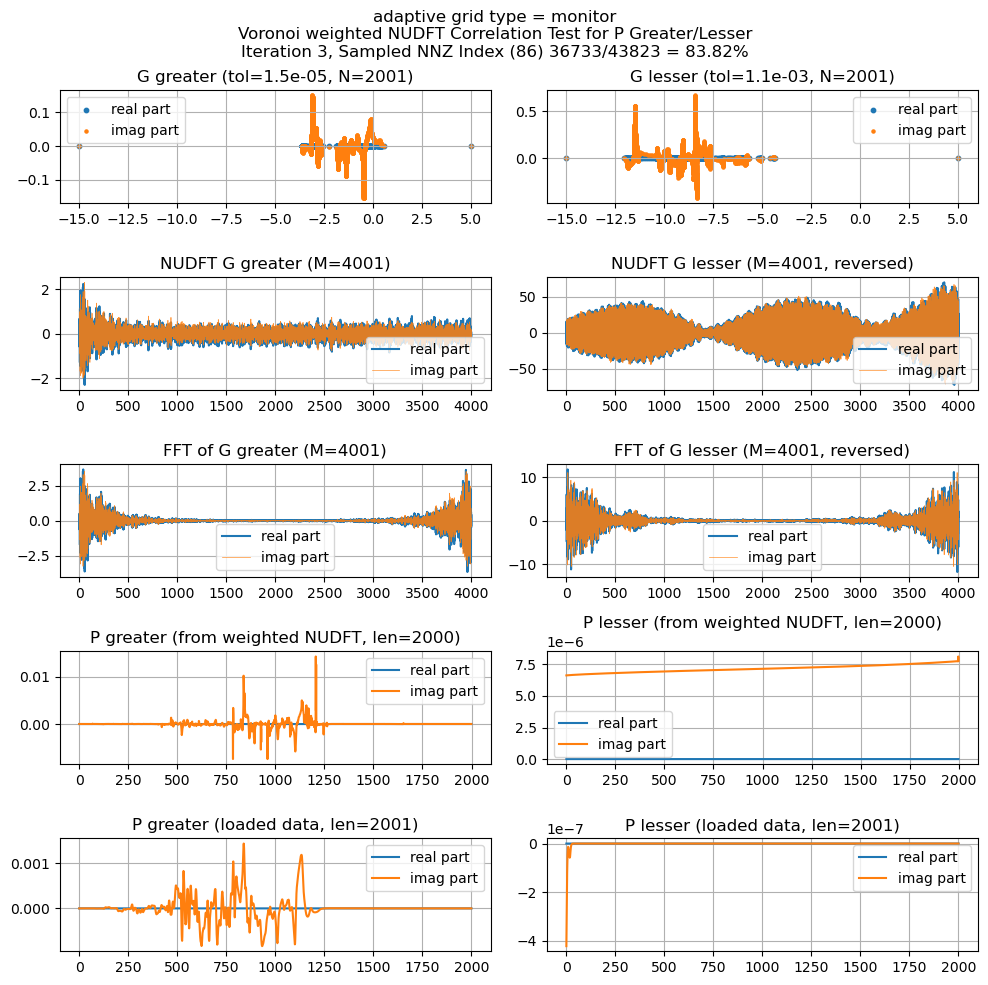

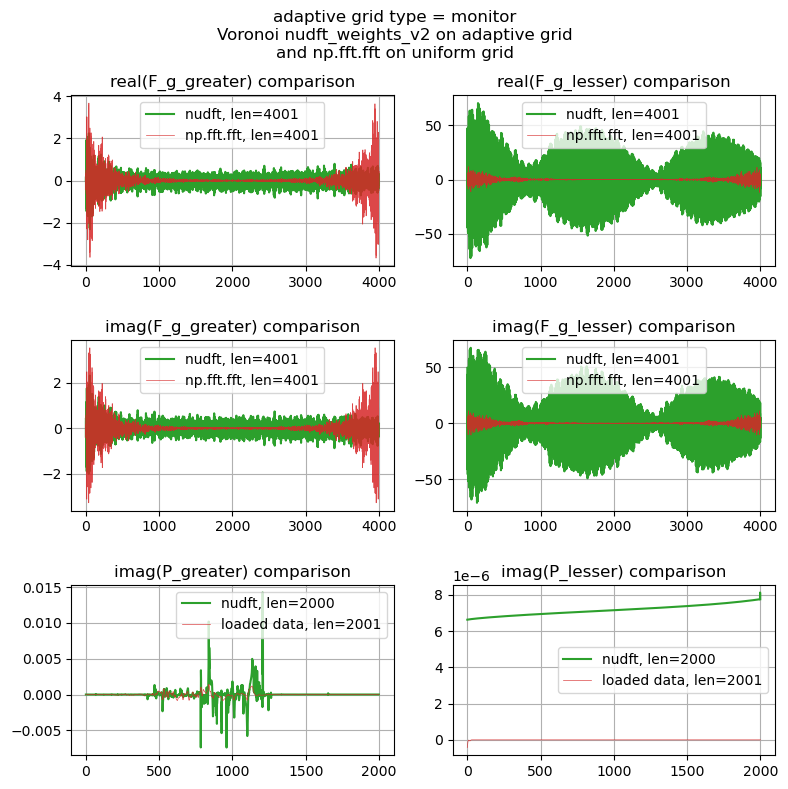

In [8]:
isPlotAll = True
isPlotDiff = True

if isPlotAll:
    fig, axs = plt.subplots(5, 2, figsize=(10, 10))

    axs[0, 0].set_title(f"G greater (tol={tol_greater:.1e}, N={len(g_greater_points)})")
    axs[0, 0].scatter(g_greater_points, C_g_greater.real, s=10, label="real part")
    axs[0, 0].scatter(g_greater_points, C_g_greater.imag, s=5, label="imag part")
    axs[0, 0].legend()
    axs[0, 0].grid()

    axs[0, 1].set_title(f"G lesser (tol={tol_lesser:.1e}, N={len(g_lesser_points)})")
    axs[0, 1].scatter(g_lesser_points, C_g_lesser.real, s=10, label="real part")
    axs[0, 1].scatter(g_lesser_points, C_g_lesser.imag, s=5, label="imag part")
    axs[0, 1].legend()
    axs[0, 1].grid()

    axs[1, 0].set_title(f"NUDFT G greater (M={M})")
    axs[1, 0].plot(np.real(F_g_greater_nudft), label="real part")
    axs[1, 0].plot(
        np.imag(F_g_greater_nudft), linewidth=0.5, alpha=0.85, label="imag part"
    )
    axs[1, 0].legend()
    axs[1, 0].grid()

    axs[1, 1].set_title(f"NUDFT G lesser (M={M}, reversed)")
    axs[1, 1].plot(np.real(F_g_lesser_nudft[::-1]), label="real part")
    axs[1, 1].plot(
        np.imag(F_g_lesser_nudft[::-1]), linewidth=0.5, alpha=0.85, label="imag part"
    )
    axs[1, 1].legend()
    axs[1, 1].grid()

    axs[2, 0].set_title(f"FFT of G greater (M={len(F_g_greater)})")
    axs[2, 0].plot(np.real(F_g_greater), label="real part")
    axs[2, 0].plot(np.imag(F_g_greater), linewidth=0.5, alpha=0.85, label="imag part")
    axs[2, 0].legend()
    axs[2, 0].grid()

    axs[2, 1].set_title(f"FFT of G lesser (M={len(F_g_lesser)}, reversed)")
    axs[2, 1].plot(np.real(F_g_lesser), label="real part")
    axs[2, 1].plot(np.imag(F_g_lesser), linewidth=0.5, alpha=0.85, label="imag part")
    axs[2, 1].legend()
    axs[2, 1].grid()

    axs[3, 0].set_title(f"P greater (from weighted NUDFT, len={len(p_greater_nudft)})")
    axs[3, 0].plot(np.real(p_greater_nudft), label="real part")
    axs[3, 0].plot(np.imag(p_greater_nudft), label="imag part")
    axs[3, 0].legend()
    axs[3, 0].grid()

    axs[3, 1].set_title(f"P lesser (from weighted NUDFT, len={len(p_lesser_nudft)})")
    axs[3, 1].plot(np.real(p_lesser_nudft), label="real part")
    axs[3, 1].plot(np.imag(p_lesser_nudft), label="imag part")
    axs[3, 1].legend()
    axs[3, 1].grid()

    axs[4, 0].set_title(f"P greater (loaded data, len={len(p_greater)})")
    axs[4, 0].plot(np.real(p_greater), label="real part")
    axs[4, 0].plot(np.imag(p_greater), label="imag part")
    axs[4, 0].legend()
    axs[4, 0].grid()

    axs[4, 1].set_title(f"P lesser (loaded data, len={len(p_lesser)})")
    axs[4, 1].plot(np.real(p_lesser), label="real part")
    axs[4, 1].plot(np.imag(p_lesser), label="imag part")
    axs[4, 1].legend()
    axs[4, 1].grid()

    fig.suptitle(
        f"adaptive grid type = {adaptive_points_type}\nVoronoi weighted NUDFT Correlation Test for P Greater/Lesser\nIteration {iteration}, Sampled NNZ Index ({sample_idx}) {nnz_index}/{max_idx} = {nnz_index/max_idx:.2%}"
    )

    plt.tight_layout()
    plt.show()

if isPlotDiff:
    fig, axe = plt.subplots(3, 2, figsize=(8, 8))
    axe[0, 0].set_title("real(F_g_greater) comparison")
    axe[0, 0].plot(
        F_g_greater_nudft.real,
        color="tab:green",
        label=f"nudft, len={len(F_g_greater_nudft)}",
    )
    axe[0, 0].plot(
        F_g_greater.real,
        color="tab:red",
        alpha=0.85,
        linewidth=0.5,
        label=f"np.fft.fft, len={len(F_g_greater)}",
    )
    axe[0, 0].grid()
    axe[0, 0].legend(loc="upper center")

    axe[0, 1].set_title("real(F_g_lesser) comparison")
    axe[0, 1].plot(
        F_g_lesser_nudft.real,
        color="tab:green",
        label=f"nudft, len={len(F_g_lesser_nudft)}",
    )
    axe[0, 1].plot(
        F_g_lesser.real,
        color="tab:red",
        alpha=0.85,
        linewidth=0.5,
        label=f"np.fft.fft, len={len(F_g_lesser)}",
    )
    axe[0, 1].grid()
    axe[0, 1].legend(loc="upper center")

    axe[1, 0].set_title("imag(F_g_greater) comparison")
    axe[1, 0].plot(
        F_g_greater_nudft.imag,
        color="tab:green",
        label=f"nudft, len={len(F_g_greater_nudft)}",
    )
    axe[1, 0].plot(
        F_g_greater.imag,
        color="tab:red",
        alpha=0.85,
        linewidth=0.5,
        label=f"np.fft.fft, len={len(F_g_greater)}",
    )
    axe[1, 0].grid()
    axe[1, 0].legend(loc="upper center")

    axe[1, 1].set_title("imag(F_g_lesser) comparison")
    axe[1, 1].plot(
        F_g_lesser_nudft.imag,
        color="tab:green",
        label=f"nudft, len={len(F_g_lesser_nudft)}",
    )
    axe[1, 1].plot(
        F_g_lesser.imag,
        color="tab:red",
        alpha=0.85,
        linewidth=0.5,
        label=f"np.fft.fft, len={len(F_g_lesser)}",
    )
    axe[1, 1].grid()
    axe[1, 1].legend(loc="upper center")

    axe[2, 0].set_title("imag(P_greater) comparison")
    axe[2, 0].plot(
        p_greater_nudft.imag,
        color="tab:green",
        label=f"nudft, len={len(p_greater_nudft)}",
    )
    axe[2, 0].plot(
        p_greater.imag,
        color="tab:red",
        alpha=0.85,
        linewidth=0.5,
        label=f"loaded data, len={len(p_greater)}",
    )
    axe[2, 0].grid()
    axe[2, 0].legend()

    axe[2, 1].set_title("imag(P_lesser) comparison")
    axe[2, 1].plot(
        p_lesser_nudft.imag,
        color="tab:green",
        label=f"nudft, len={len(p_lesser_nudft)}",
    )
    axe[2, 1].plot(
        p_lesser.imag,
        color="tab:red",
        alpha=0.85,
        linewidth=0.5,
        label=f"loaded data, len={len(p_lesser)}",
    )
    axe[2, 1].grid()
    axe[2, 1].legend()

    fig.suptitle(
        f"adaptive grid type = {adaptive_points_type}\nVoronoi nudft_weights_v2 on adaptive grid\nand np.fft.fft on uniform grid"
    )
    plt.tight_layout()
    plt.show()

# Enforcing conjugate symmetry
Tue, Dec 23, 2025

The NUDFT gives decent results on the left-half of the Fourier transform. However the right half looks bad, because the conjugate symmetry of the FFT is lost due to non-uniform spacing. Let's try enforcing this conjugate symmetry. We'll take the first M/2 output modes and just flip it to create a "force_conjugate" nudft. Since the output lengths can be different, we'll use the FFT length as the standard length where we do the flip. This means that the nudft will often be a not true conjugate flip, since we only enforce the symmetry on a shorter left-half than required. 

Ex. FFT length = 1024. NUDFT length = 2121. 
- choose "halfway" to be FFT length/2 = 512
- only take the first 512 points of NUDFT
    - not a true conjugate flip


Answer (Tue, Dec 30, 2025): Doesn't change much. The polarization data still doesn't match exactly the loaded np.fft.fft data. The root cause is that the Fourier transform is already different magnitudes. See OneNote > For Anders and AlexNick > Proposed Ideas > chart entry "non-uniform grid - enforce conjugate symmetry".

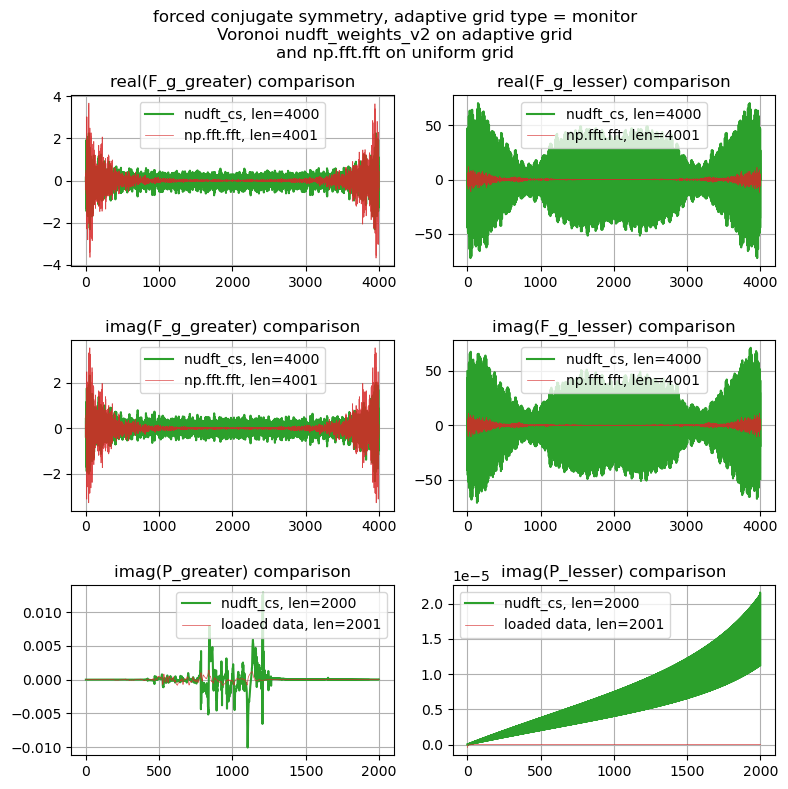

In [9]:
def enforce_conjugate_symmetry(arr, length):
    """Enforce conjugate symmetry on a 1D array to make it suitable for real-valued inverse FFT.
    Parameters:
        arr (np.ndarray): Input 1D array of complex numbers.
        length (int): Desired length of the output array after enforcing symmetry.
    Returns:
        np.ndarray: Array with enforced conjugate symmetry.
    """
    split_idx = length // 2
    left_half = arr[:split_idx]
    right_half_forced_conjugate = left_half.conj()[::-1]
    return np.concatenate([left_half, right_half_forced_conjugate])


output_length = 2 * len(SCBADataObj.energies) - 1

# `_cs` means "conjugate symmetry enforced"
F_g_greater_nudft_cs = enforce_conjugate_symmetry(F_g_greater_nudft, output_length)
F_g_lesser_nudft_cs = enforce_conjugate_symmetry(F_g_lesser_nudft, output_length)

# compute P greater/lesser from the enforced conjugate symmetry versions
prefactor = -1j / np.pi * np.abs(SCBADataObj.energies[1] - SCBADataObj.energies[0])
p_greater_nudft_cs = prefactor * np.fft.ifft(F_g_greater_nudft_cs * F_g_lesser_nudft_cs)
p_lesser_nudft_cs = -1 * p_greater_nudft_cs[::-1].conj()

# take the "second" part of the correlation result to match the size
Ne = len(SCBADataObj.energies)
p_greater_nudft_cs = p_greater_nudft_cs[Ne - 1 :]
p_lesser_nudft_cs = p_lesser_nudft_cs[Ne - 1 :]

# discord the real part
p_greater_nudft_cs = 1j * np.imag(p_greater_nudft_cs)
p_lesser_nudft_cs = 1j * np.imag(p_lesser_nudft_cs)

isPlotDiff = True
if isPlotDiff:
    fig, axe = plt.subplots(3, 2, figsize=(8, 8))
    axe[0, 0].set_title("real(F_g_greater) comparison")
    axe[0, 0].plot(
        F_g_greater_nudft_cs.real,
        color="tab:green",
        label=f"nudft_cs, len={len(F_g_greater_nudft_cs)}",
    )
    axe[0, 0].plot(
        F_g_greater.real,
        color="tab:red",
        alpha=0.85,
        linewidth=0.5,
        label=f"np.fft.fft, len={len(F_g_greater)}",
    )
    axe[0, 0].grid()
    axe[0, 0].legend(loc="upper center")

    axe[0, 1].set_title("real(F_g_lesser) comparison")
    axe[0, 1].plot(
        F_g_lesser_nudft_cs.real,
        color="tab:green",
        label=f"nudft_cs, len={len(F_g_lesser_nudft_cs)}",
    )
    axe[0, 1].plot(
        F_g_lesser.real,
        color="tab:red",
        alpha=0.85,
        linewidth=0.5,
        label=f"np.fft.fft, len={len(F_g_lesser)}",
    )
    axe[0, 1].grid()
    axe[0, 1].legend(loc="upper center")

    axe[1, 0].set_title("imag(F_g_greater) comparison")
    axe[1, 0].plot(
        F_g_greater_nudft_cs.imag,
        color="tab:green",
        label=f"nudft_cs, len={len(F_g_greater_nudft_cs)}",
    )
    axe[1, 0].plot(
        F_g_greater.imag,
        color="tab:red",
        alpha=0.85,
        linewidth=0.5,
        label=f"np.fft.fft, len={len(F_g_greater)}",
    )
    axe[1, 0].grid()
    axe[1, 0].legend(loc="upper center")

    axe[1, 1].set_title("imag(F_g_lesser) comparison")
    axe[1, 1].plot(
        F_g_lesser_nudft_cs.imag,
        color="tab:green",
        label=f"nudft_cs, len={len(F_g_lesser_nudft_cs)}",
    )
    axe[1, 1].plot(
        F_g_lesser.imag,
        color="tab:red",
        alpha=0.85,
        linewidth=0.5,
        label=f"np.fft.fft, len={len(F_g_lesser)}",
    )
    axe[1, 1].grid()
    axe[1, 1].legend(loc="upper center")

    axe[2, 0].set_title("imag(P_greater) comparison")
    axe[2, 0].plot(
        p_greater_nudft_cs.imag,
        color="tab:green",
        label=f"nudft_cs, len={len(p_greater_nudft_cs)}",
    )
    axe[2, 0].plot(
        p_greater.imag,
        color="tab:red",
        alpha=0.85,
        linewidth=0.5,
        label=f"loaded data, len={len(p_greater)}",
    )
    axe[2, 0].grid()
    axe[2, 0].legend()

    axe[2, 1].set_title("imag(P_lesser) comparison")
    axe[2, 1].plot(
        p_lesser_nudft_cs.imag,
        color="tab:green",
        label=f"nudft_cs, len={len(p_lesser_nudft_cs)}",
    )
    axe[2, 1].plot(
        p_lesser.imag,
        color="tab:red",
        alpha=0.85,
        linewidth=0.5,
        label=f"loaded data, len={len(p_lesser)}",
    )
    axe[2, 1].grid()
    axe[2, 1].legend()

    fig.suptitle(
        f"forced conjugate symmetry, adaptive grid type = {adaptive_points_type}\nVoronoi nudft_weights_v2 on adaptive grid\nand np.fft.fft on uniform grid"
    )
    plt.tight_layout()
    plt.show()

# Hilbert transform with only Fourier Transforms
Tue, February 10, 2026

We currently compute the Hilbert transform. This is done when computing the correlation part of the retarded self-energy, in the principal part of the integral.

$$
\Sigma^R_{corr, ij}(E) = -\frac{i}{2}\Gamma_{ij}(E) + \mathcal{P} \int_{E} \frac{dE'}{2\pi} \frac{\Gamma_{ij}(E')}{E-E'}
$$

where $\mathcal{P}$ is the principal part of the integral (integrate around singularities):
$$
\mathcal{P} \int_a^c f(x) = \lim_{\epsilon \to 0} \int_a^{b-\epsilon} f(x) + \int_{b-\epsilon}^{c} f(x)
$$

and $\Gamma_{ij}$ is the broadening function:
$$
\Gamma_{ij} = i [\Sigma^\gt_{GW,ij} - \Sigma^\lt_{GW,ij}]
$$

The Hilbert transform takes a function $u(t)$ and transforms it to $H(u)(t)$. It convolves $u(t)$ with $\frac{1}{\pi t}$. Depending on definitions, there may or may not be a $\pi$ in the denominator. The convolution looks like:
$$
H(u)(t) = \frac{1}{\pi} \mathcal{P} \int^{+\infty}_{-\infty} \frac{u(\tau)}{t-\tau} d\tau
$$

We can compute the convolution in frequency space:
$$
H(u)(t) = \mathcal{F}^{-1} \{ \mathcal{F}\{ u(t)\} * \mathcal{F}\{\frac{1}{\pi t}\} \}
$$

The Fourier transform of the $\frac{1}{\pi t}$ is the Hilbert kernel.
$$
\mathcal{F}\left( \frac{1}{\pi t} \right)= -i \text{sgn}(\omega)
$$

where $\text{sgn}(x)$ is the sign function (returns +1, 0, or -1 depending on the sign of x).

But for some reason, the implementation in Quatrex of the Hilbert kernel directly computes `np.fft.fft(1/(reshaped_energies + eta))`. The `reshaped_energies` is going from -5 to 15eV to be a domain compatible for the convolution: 0 to 20eV (`energies - energies[0]`). Then it's reshaped from (N,) to (N,1). The `eta` is a small value 1e-8 to make sure the zeroth value in `reshaped_energies[0]` (which is zero) doesn't lead to a singularity by doing 1/0.

In [10]:
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

data_dir = Path("./outputs")

sigma_greater = np.load(data_dir / "SigmaCoulombScreening_sigma_greater.npy")
sigma_lesser = np.load(data_dir / "SigmaCoulombScreening_sigma_lesser.npy")
sigma_retarded = np.load(data_dir / "SigmaCoulombScreening_sigma_retarded.npy")
antihermitian = np.load(data_dir / "SigmaCoulombScreening_antihermitian.npy")
energies = np.load(data_dir / "SigmaCoulombScreening_energies.npy")
energy_differences = np.load(data_dir / "SigmaCoulombScreening_energy_differences.npy")
eta = np.load(data_dir / "SigmaCoulombScreening_eta.npy")
hilbert_kernel_fft = np.load(data_dir / "SigmaCoulombScreening_hilbert_kernel_fft.npy")
prefactor = np.load(data_dir / "SigmaCoulombScreening_prefactor.npy")



FileNotFoundError: [Errno 2] No such file or directory: 'outputs/SigmaCoulombScreening_sigma_greater.npy'

In [ ]:
# energy_differences reshapes from to (Ne,) to (Ne,1)
# np.allclose(np.fft.fft(1/(energy_differences+eta), n=len(energies)*2-1, axis=0), hilbert_kernel_fft)
# np.allclose(np.fft.fft(1/(energies-energies[0]+eta), n=len(energies)*2-1, axis=0), hilbert_kernel_fft)

hilbert_kernel_direct = 1/(energies-energies[0]+eta)
hilbert_kernel_direct_fft = np.fft.fft(hilbert_kernel_direct, n=len(energies)*2-1, axis=0)
print(f"Direct computation vs loaded hilbert kernel fft close: {np.allclose(hilbert_kernel_direct_fft, hilbert_kernel_fft)}")

## test of Hilbert transform and fourier transform relationship
Not trying to recreate Quatrex data. Just seeing if H(u) = iFFT( -i*sign(omega) * FFT(u) ). Use the input data as gamma = sigma_greater-sigma_lesser for just one orbital.

0. Hilbert transform using explicit convolution
1. Hilbert transform via Hilbert kernel (Quatrex method, direct computation) 
2. Hilbert transform on uniform grid FFT (indirect) 
3. Hilbert transform using non-uniform grid nfft (indirect) 

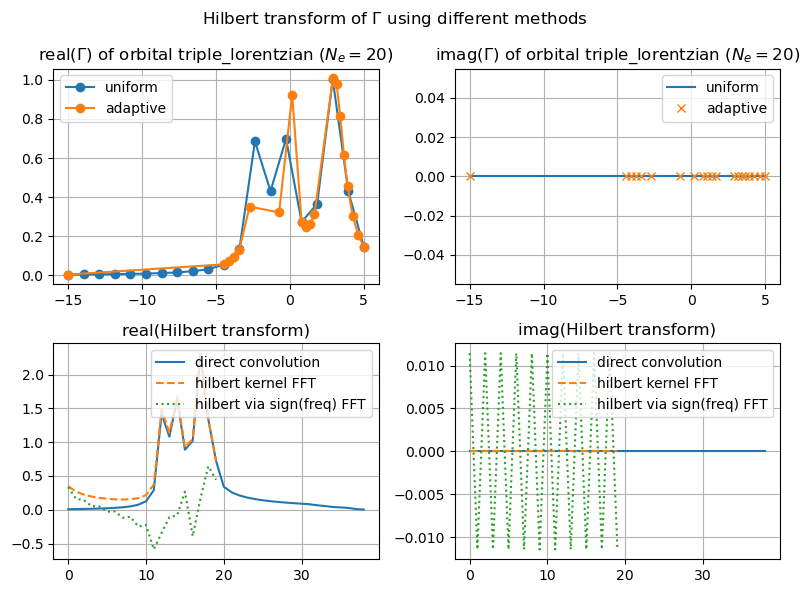

In [11]:
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
import scipy.signal
import finufft

# data_dir = Path("./outputs")
# sigma_greater = np.load(data_dir / "SigmaCoulombScreening_sigma_greater.npy")
# sigma_lesser = np.load(data_dir / "SigmaCoulombScreening_sigma_lesser.npy")
# energies = np.load(data_dir / "SigmaCoulombScreening_energies.npy")

# n_orbital = 20001     # 0 to 43823
# gamma = -1j * (sigma_greater - sigma_lesser)
# u = gamma[:, n_orbital]

# triple lorentzian function with some randomness
def f(x, random=False):
    def lorentzian(x, x0, gamma):
        return gamma**2 / ((x - x0)**2 + gamma**2)
    def triple_lorentzian(x, random=False):
        if random:
            x0s = np.random.uniform(-10, 0, size=3)
            gammas = np.random.uniform(0.1, 1.0, size=3)
        else:
            x0s = [-2, 0, 3]
            gammas = [0.5, 0.3, 0.8]
        y = sum(lorentzian(x, x0, gamma) for x0, gamma in zip(x0s, gammas))
        return y
    return triple_lorentzian(x, random=random)

def monitor(fp, type='gradient'):
    """Monitor function for adaptive integration."""
    if type == 'gradient':
        # return the absolute gradient as the monitor function
        #   lose the real/imag parts here
        # return np.abs(np.diff(fp, prepend=fp[0])) # prepend to keep the same length
        return np.abs(np.gradient(fp))
    elif type == 'curvature':
        # return the absolute second derivative as the monitor function
        return np.abs(np.gradient(np.gradient(fp)))
    else:
        raise ValueError("Unknown monitor type. Use 'gradient' or 'curvature'.")
    
def adaptive_points_from_monitor(fp, xp, monitor_type='gradient', N_target=100):
    """Generate adaptive points based on the monitor function."""
    M = monitor(fp, type=monitor_type)
    C = np.cumsum(M)
    C = C/C[-1]  # normalize to [0, 1]

    targets = np.linspace(0, 1, N_target)
    # reverse the (x,y) to (y,x) for interpolation back to the original x-axis (energy grid)
    adaptive_points = np.interp(targets, C, xp)
    return adaptive_points, M, C

N = 20
N_target = N
n_orbital = "triple_lorentzian"
energies = np.linspace(-15, 5, N)
dE = energies[1] - energies[0]
u = f(energies, random=False) #+ 1j * f(energies, random=False)
energies_adaptive, M, C = adaptive_points_from_monitor(u, energies, monitor_type='gradient', N_target=N_target)
u_adaptive = f(energies_adaptive, random=False) #+ 1j * f(energies_adaptive, random=False)
u_adaptive = u_adaptive.astype(np.complex128)  # convert to complex128 for finufft

# method 0: Hilbert transform using direct computation
def h(t, eta=1e-8):
    return 1/(np.pi*t+eta)

hilbert0 = np.convolve(u, h(energies-energies[0], eta=dE/2), mode='full') * (energies[1]-energies[0])

# method 1: Hilbert transform using Hilbert kernel FFT (direct)
hilbert_kernel = h(energies-energies[0], eta=dE/2)
hilbert_kernel_fft = np.fft.fft(hilbert_kernel)
u_fft = np.fft.fft(u)
hilbert1 = np.fft.ifft(hilbert_kernel_fft * u_fft) * (energies[1]-energies[0])

# method 2: Hilbert transform on uniform grid FFT (indirect)
u_fft = np.fft.fft(u)
freq = np.fft.fftfreq(len(energies), d=energies[1]-energies[0])
H = -1j * np.sign(freq)
H[0] = 0.0
hilbert2 = np.fft.ifft(H * u_fft) 

# method 3: Hilbert transform from scipy
# hilbert3 = scipy.signal.hilbert(u)  # input must be real, designed for analytic signals, not suitable for us

# method 3: Hilbert transform using non-uniform fourier transforms
u_nfft = finufft.nufft1d1(energies_adaptive, u_adaptive, eps=1e-12, n_modes=N_target)
temp = u_nfft * hilbert_kernel_fft
hilbert3 = finufft.nufft1d2(x=energies_adaptive, f=temp, eps=1e-12) * (energies[1]-energies[0])

# region: === plotting ===
fig, axs = plt.subplots(2,2, figsize=(8,6))

# adaptive points
axs[0,0].set_title(f"real($\\Gamma$) of orbital {n_orbital} ($N_e = {len(u)}$)")
axs[0,0].plot(energies, u.real, '-o', label="uniform")
axs[0,0].plot(energies_adaptive, u_adaptive.real, '-o', label="adaptive")
axs[0,0].legend()
axs[0,0].grid()

axs[0,1].set_title(f"imag($\\Gamma$) of orbital {n_orbital} ($N_e = {len(u)}$)")
axs[0,1].plot(energies, u.imag, label="uniform")
axs[0,1].plot(energies_adaptive, u_adaptive.imag, 'x', color="tab:orange", label="adaptive")
axs[0,1].legend()
axs[0,1].grid()

# transform results
axs[1,0].set_title("real(Hilbert transform)")
axs[1,0].plot(hilbert0.real, label="direct convolution")
axs[1,0].plot(hilbert1.real, label="hilbert kernel FFT", linestyle="dashed")
axs[1,0].plot(hilbert2.real, label="hilbert via sign(freq) FFT", linestyle="dotted")
# axs[1,0].plot(hilbert3.real, label="nfft hilbert", linestyle="dashdot")
axs[1,0].legend()
axs[1,0].grid()

axs[1,1].set_title("imag(Hilbert transform)")
axs[1,1].plot(hilbert0.imag, label="direct convolution")
axs[1,1].plot(hilbert1.imag, label="hilbert kernel FFT", linestyle="dashed")
axs[1,1].plot(hilbert2.imag, label="hilbert via sign(freq) FFT", linestyle="dotted")
# axs[1,1].plot(hilbert3.imag, label="nfft hilbert", linestyle="dashdot")
axs[1,1].legend()
axs[1,1].grid()

fig.suptitle("Hilbert transform of $\\Gamma$ using different methods")
plt.tight_layout()
plt.show()

# endregion


In [12]:
H.imag

array([ 0., -1., -1., -1., -1., -1., -1., -1., -1., -1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.])

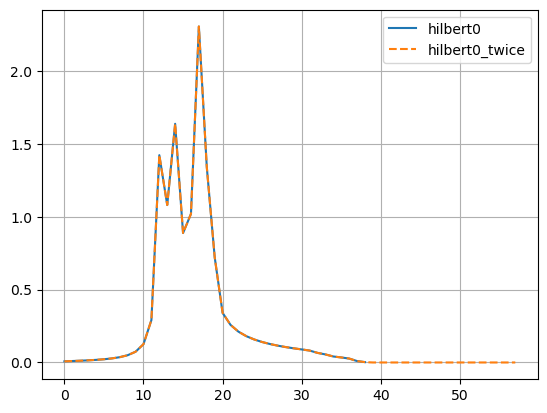

In [13]:
# hilbert transform 2x should give original function back with a negative sign
hilbert0_twice = np.convolve(hilbert0, h(energies-energies[0]), mode='full') * (energies[1]-energies[0])
# print(f"Hilbert of Hilbert close to original (with negative sign): {np.allclose(-u, hilbert0_of_hilbert0)}")

# plt.plot(-u.imag, label="-u")
plt.plot(hilbert0.real, label="hilbert0")
plt.plot(hilbert0_twice.real * hilbert0.real[0]/hilbert0_twice.real[0], '--', label="hilbert0_twice")
plt.legend()
plt.grid()
plt.show()

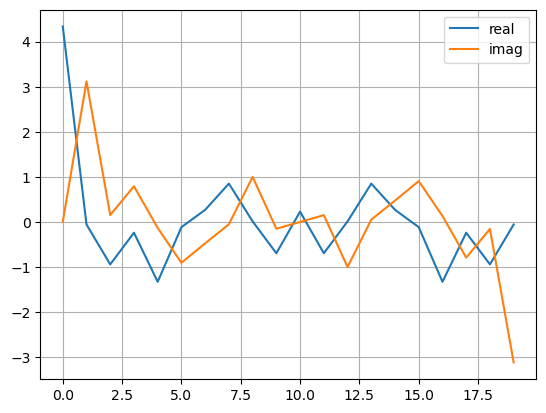

In [14]:
plt.plot(u_fft.real, label="real")
plt.plot(u_fft.imag, label="imag")
plt.legend()
plt.grid()
plt.show()

In [15]:
np.sign(freq)

array([ 0.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1.])

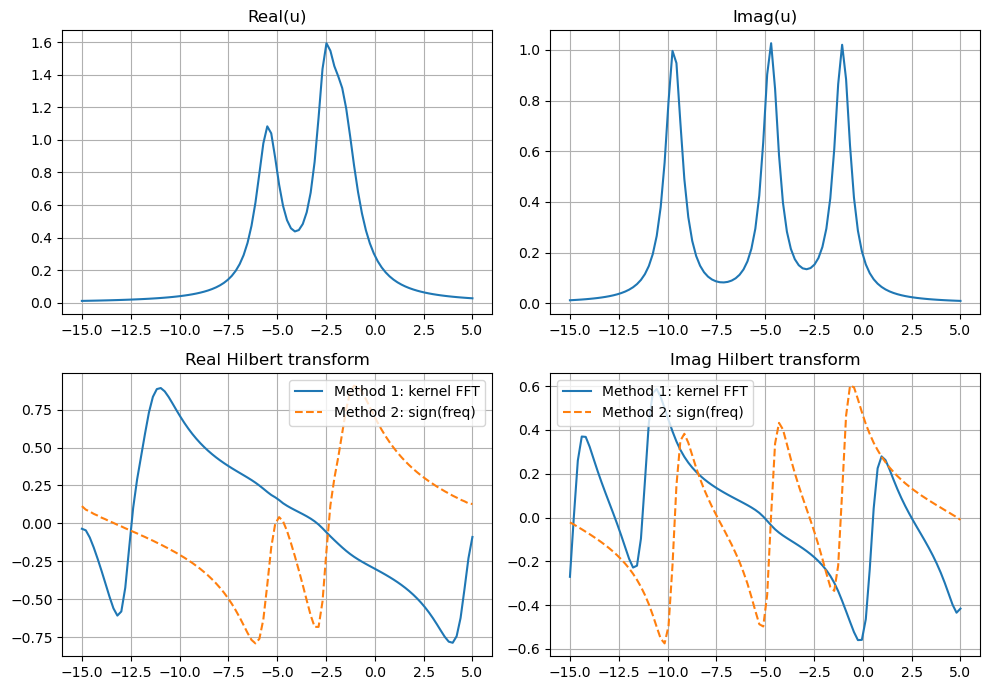

In [16]:
# CoPilot generated code
import numpy as np
import matplotlib.pyplot as plt

# --- test function -----------------------------------------------------------
def f(x, random=False):
    def lorentzian(x, x0, gamma):
        return gamma**2 / ((x - x0)**2 + gamma**2)
    if random:
        x0s = np.random.uniform(-10, 0, size=3)
        gammas = np.random.uniform(0.1, 1.0, size=3)
    else:
        x0s = [-2, 0, 3]
        gammas = [0.5, 0.3, 0.8]
    return sum(lorentzian(x, x0, gamma) for x0, gamma in zip(x0s, gammas))

# --- grid -------------------------------------------------------------------
N = 100
energies = np.linspace(-15, 5, N)
dE = energies[1] - energies[0]

# complex test signal
u = f(energies, random=True) + 1j * f(energies, random=True)

# ============================================================================
# METHOD 1: Hilbert transform via FFT of the kernel
# ============================================================================

# build symmetric Hilbert kernel 1/(π t) with PV at t=0
t = energies - energies[N//2]
hilbert_kernel = np.zeros_like(t)
mask = t != 0
hilbert_kernel[mask] = 1.0 / (np.pi * t[mask])
hilbert_kernel[N//2] = 0.0   # PV

# FFT-based convolution (same length N)
Hk_fft = np.fft.fft(hilbert_kernel)
u_fft = np.fft.fft(u)

hilbert1 = np.fft.ifft(Hk_fft * u_fft) * dE  # scale by grid spacing

# ============================================================================
# METHOD 2: Hilbert transform via -i * sign(freq)
# ============================================================================

freq = np.fft.fftfreq(N, d=dE)
H = -1j * np.sign(freq)
H[0] = 0.0

hilbert2 = np.fft.ifft(H * u_fft)

# ============================================================================
# PLOTTING
# ============================================================================
fig, axs = plt.subplots(2, 2, figsize=(10, 7))

axs[0,0].set_title("Real(u)")
axs[0,0].plot(energies, u.real)
axs[0,0].grid()

axs[0,1].set_title("Imag(u)")
axs[0,1].plot(energies, u.imag)
axs[0,1].grid()

axs[1,0].set_title("Real Hilbert transform")
axs[1,0].plot(energies, hilbert1.real, label="Method 1: kernel FFT")
axs[1,0].plot(energies, hilbert2.real, '--', label="Method 2: sign(freq)")
axs[1,0].legend()
axs[1,0].grid()

axs[1,1].set_title("Imag Hilbert transform")
axs[1,1].plot(energies, hilbert1.imag, label="Method 1: kernel FFT")
axs[1,1].plot(energies, hilbert2.imag, '--', label="Method 2: sign(freq)")
axs[1,1].legend()
axs[1,1].grid()

plt.tight_layout()
plt.show()


In [17]:
freq

array([ 0.    ,  0.0495,  0.099 ,  0.1485,  0.198 ,  0.2475,  0.297 ,
        0.3465,  0.396 ,  0.4455,  0.495 ,  0.5445,  0.594 ,  0.6435,
        0.693 ,  0.7425,  0.792 ,  0.8415,  0.891 ,  0.9405,  0.99  ,
        1.0395,  1.089 ,  1.1385,  1.188 ,  1.2375,  1.287 ,  1.3365,
        1.386 ,  1.4355,  1.485 ,  1.5345,  1.584 ,  1.6335,  1.683 ,
        1.7325,  1.782 ,  1.8315,  1.881 ,  1.9305,  1.98  ,  2.0295,
        2.079 ,  2.1285,  2.178 ,  2.2275,  2.277 ,  2.3265,  2.376 ,
        2.4255, -2.475 , -2.4255, -2.376 , -2.3265, -2.277 , -2.2275,
       -2.178 , -2.1285, -2.079 , -2.0295, -1.98  , -1.9305, -1.881 ,
       -1.8315, -1.782 , -1.7325, -1.683 , -1.6335, -1.584 , -1.5345,
       -1.485 , -1.4355, -1.386 , -1.3365, -1.287 , -1.2375, -1.188 ,
       -1.1385, -1.089 , -1.0395, -0.99  , -0.9405, -0.891 , -0.8415,
       -0.792 , -0.7425, -0.693 , -0.6435, -0.594 , -0.5445, -0.495 ,
       -0.4455, -0.396 , -0.3465, -0.297 , -0.2475, -0.198 , -0.1485,
       -0.099 , -0.0

# Band-limited study

Fri, Feb 27, 2026

Is the "signal" from the Green's function actually band-limited? The standard assumption in all the non-uniform sampling reconstruction papers is that the signal is band-limited. It means that after some frequency $f_m$, the spectrum of the signal is $f_k=0$. High frequency signals should decay to zero. In addition, the number of Fourier modes $M$ is $0 < |M/2| < N$. As it applies to `np.fft.fft`, it means the transform output is the same length as the input. Aka `np.fft.fft(x, n=x.shape[0])` or you can just do `np.fft.fft(x)` since that's the default behaviour. No oversampling of the Fourier modes is allowed. This preserves the Nyquist criterion to make sure that you if you have $N$ non-uniform samples (think of them as being perturbed uniform samples), then you can only perfectly reconstruct signals of frequency $M=N/2$.

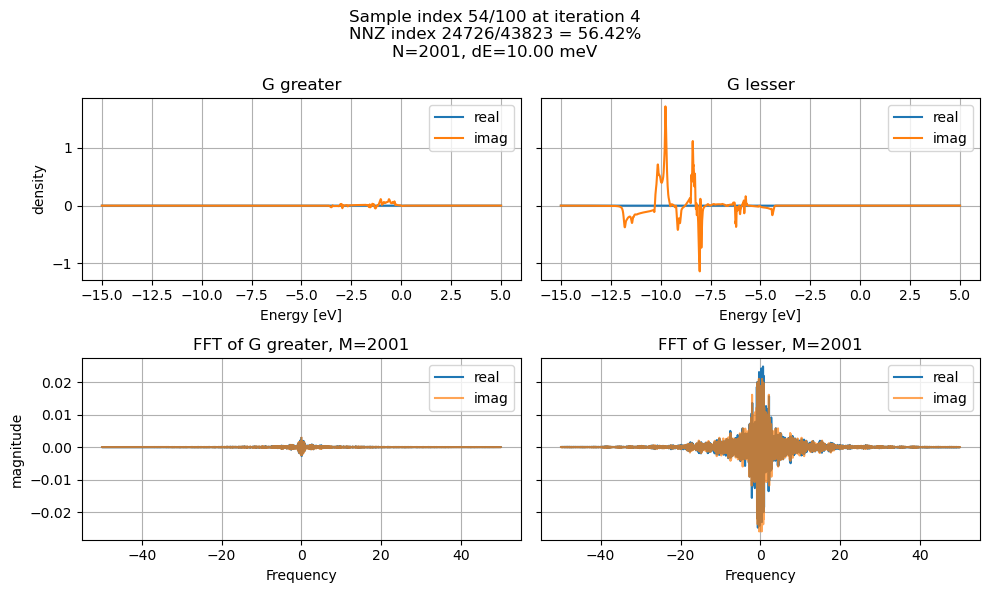

In [66]:
# load data
import numpy as np
from quatrex.core.config import parse_config
from pathlib import Path
from matplotlib import pyplot as plt

from scba_container.scba_container import SCBAContainer

# 20260226_152224_energy201_iter20_reduced
# 20260226_155038_energy2001_iter5_reduced
# 20260227_113823_energy20001_iter5_reduced

simulation_dir = Path("./../../examples/w90/carbon-nanotube/gw")
output_dir = simulation_dir / "outputs"
output_file_prefix = output_dir / "visualize_scba"
archive_dir = simulation_dir / "archive" / "20260226_155038_energy2001_iter5_reduced"
archive_file_prefix = archive_dir / "visualize_scba"

# change these to switch between 'output' and 'archive'
data_files = 'archive'

# === user parameters ===
iteration = 4
sample_idx = 54

method = 'single' # options: 'sum_then_fft' or 'fft_then_sum' or 'single' (use the single sample without summing)

# region: === load data ===
if data_files == 'output':
    data_file_prefix = output_file_prefix
    config_dir = simulation_dir
elif data_files == 'archive':
    data_file_prefix = archive_file_prefix
    config_dir = archive_dir
else:
    raise ValueError(f"Invalid data_files value: {data_files}. Must be 'output' or 'archive'.")

config = parse_config(config_dir / "quatrex_config.toml")

max_idx = 43823  # total nnz entries - 1
sample_indices = np.load(f"{data_file_prefix}_sample_indices.npy")
num_samples = len(sample_indices)

SCBADataObj = SCBAContainer(
    max_iterations=config.scba.max_iterations,
    energy_window_min=config.electron.energy_window_min,
    energy_window_max=config.electron.energy_window_max,
    energy_window_num=config.electron.energy_window_num,
    num_samples=num_samples,
)

SCBADataObj.load_sample_indices(data_file_prefix)

for i in range(config.scba.max_iterations):
    SCBADataObj.load_g_data(data_file_prefix, iteration=i)
    SCBADataObj.load_p_data(data_file_prefix, iteration=i)
    SCBADataObj.load_w_data(data_file_prefix, iteration=i)
    SCBADataObj.load_sigma_data(data_file_prefix, iteration=i)

assert (
    sample_idx <= num_samples
), f"sample_idx={sample_idx} exceeds num_samples={num_samples}"
nnz_index = SCBADataObj.sample_indices[sample_idx]
# endregion

# region: === FFT computation ===
if method == 'sum_then_fft':
    # {iteration, energy, nnz}
    g_lesser = np.sum(np.abs(SCBADataObj.g_lesser[iteration, :, :]), axis=1)        # output is 1-D array of length N_energies
    g_greater = np.sum(np.abs(SCBADataObj.g_greater[iteration, :, :]), axis=1)

    G_lesser = np.fft.fft(g_lesser, axis=0) / g_lesser.shape[0]  # normalize by length for consistency with ifft
    G_greater = np.fft.fft(g_greater, axis=0) / g_greater.shape[0]

elif method == 'fft_then_sum':
    g_lesser = SCBADataObj.g_lesser[iteration, :, :]        # take all nnz samples for the given iteration, output shape is (N_energies, num_samples)
    g_greater = SCBADataObj.g_greater[iteration, :, :]

    G_lesser = np.fft.fft(g_lesser, axis=0) / g_lesser.shape[0]  # fft across 1st dimension = energy
    G_greater = np.fft.fft(g_greater, axis=0) / g_greater.shape[0]  # normalize by length for consistency with ifft

    G_lesser = np.sum(np.abs(G_lesser), axis=1)     # sum across the nnz dimension, output is 1-D array of length N_energies
    G_greater = np.sum(np.abs(G_greater), axis=1)

elif method == 'single':
    g_lesser = SCBADataObj.g_lesser[iteration, :, sample_idx]
    g_greater = SCBADataObj.g_greater[iteration, :, sample_idx]

    G_lesser = np.fft.fft(g_lesser, axis=0) / len(g_lesser)  # normalize by length for consistency with ifft
    G_greater = np.fft.fft(g_greater, axis=0) / len(g_greater)
else:
    raise ValueError(f"Invalid method: {method}. Must be 'sum_then_fft', 'fft_then_sum', or 'single'.")
# endregion


# region: === plotting ===
fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharey='row')

fftfreq = np.fft.fftfreq(len(SCBADataObj.energies), d=SCBADataObj.energies[1] - SCBADataObj.energies[0])

if method == 'sum_then_fft' or method == 'fft_then_sum':
    plt.suptitle(f"method = {method}\nsample $N_{{nnz}}$ = {len(sample_indices)} at iteration {iteration}\nN={len(SCBADataObj.energies)}, dE={20/(len(SCBADataObj.energies)-1)*1000:.2f} meV")
elif method == 'single':
    plt.suptitle(f"Sample index {sample_idx}/{len(sample_indices)} at iteration {iteration}\nNNZ index {nnz_index}/{max_idx} = {nnz_index/max_idx:.2%}\nN={len(SCBADataObj.energies)}, dE={20/(len(SCBADataObj.energies)-1)*1000:.2f} meV")  

if method == 'single':
    axs[0,0].set_title(f"G greater")
    axs[0,0].plot(SCBADataObj.energies, g_greater.real, label="real")
    axs[0,0].plot(SCBADataObj.energies, g_greater.imag, label="imag")
    axs[0,0].set_xlabel("Energy [eV]")
    axs[0,0].set_ylabel("density")
    axs[0,0].legend()
    axs[0,0].grid()

    axs[0,1].set_title(f"G lesser")
    axs[0,1].plot(SCBADataObj.energies, g_lesser.real, label="real")
    axs[0,1].plot(SCBADataObj.energies, g_lesser.imag, label="imag")
    axs[0,1].set_xlabel("Energy [eV]")
    axs[0,1].legend()   
    axs[0,1].grid()

axs[1,0].set_title(f"FFT of G greater, M={len(G_greater)}")
axs[1,0].plot(fftfreq, G_greater.real, label="real")
axs[1,0].plot(fftfreq, G_greater.imag, alpha=0.7, label="imag")
axs[1,0].set_xlabel("Frequency")
axs[1,0].set_ylabel("magnitude")
axs[1,0].legend()
axs[1,0].grid()

axs[1,1].set_title(f"FFT of G lesser, M={len(G_lesser)}")
axs[1,1].plot(fftfreq, G_lesser.real, label="real")
axs[1,1].plot(fftfreq, G_lesser.imag, alpha=0.7, label="imag")
axs[1,1].set_xlabel("Frequency")
axs[1,1].legend()
axs[1,1].grid()

plt.tight_layout()
plt.show()
# endregion

# expriment: scipy.signal.fftconvolve

Tue, Mar 3, 2026

I'm starting to make changes to quatrex to make it work on an adaptive grid. I saw the fft_convolve function that's defined in qttools/fft/ffts.py. There's a scipy.signal.fftconvolve function that does the same thing. I tried it with some Quatrex data.

- https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.fftconvolve.html#scipy.signal.fftconvolve

findings:
- without batching, scipy.signal.fftconvolve is a ~35% faster
- with batching (size 100), scipy.signa.fftconvolve is ~78% slower
- quatrex fft_convolve returns length $2N$ instead of $2N-1$ The comment notes that this is needed for the Hilbert Transform.

Maybe you can consider it for a micro-optimization speedup. Would require "fixing" (?) the Hilbert Transform to work with length.

Anders (03 March 2026): The hilbert calculation needs some refactoring (for example straighten out the $2N$ and $2N-1$ discrepency). I might open a pull request later this week

In [19]:
import numpy as np
import scipy

use_nnz_batching = True
sample_idx = 0  # only used if use_nnz_batching is False

print(f"Testing convolution of G greater and G lesser for iteration {iteration}")

if use_nnz_batching:
    print(f"Using nnz batching: N_nnz = {len(sample_indices)}")
    g_lesser = SCBADataObj.g_lesser[iteration, :, :]
    g_greater = SCBADataObj.g_greater[iteration, :, :]
else:
    print(f"Using single sample index {sample_idx}/{len(sample_indices)}")
    g_lesser = SCBADataObj.g_lesser[iteration, :, sample_idx]
    g_greater = SCBADataObj.g_greater[iteration, :, sample_idx]

%timeit ret_scipy = scipy.signal.fftconvolve(g_greater, g_lesser, mode='full')
print(f"scipy.signal.fftconvolve result length: {ret_scipy.shape[0]}, expected length: {2*g_greater.shape[0]-1}")

def fft_convolve(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Computes the convolution of two arrays using FFT over the first axis (energy axis).

    Parameters
    ----------
    a : np.ndarray
        First array.
    b : np.ndarray
        Second array.

    Returns
    -------
    np.ndarray
        The convolution of the two arrays.
    """
    ne = (
        a.shape[0] + b.shape[0]
    )  # Should not have -1 here (otherwise hilbert transform fails)
    a_fft = np.fft.fft(a, ne, axis=0)
    b_fft = np.fft.fft(b, ne, axis=0)
    return np.fft.ifft(a_fft * b_fft, axis=0)

%timeit ret_quatrex = fft_convolve(g_greater, g_lesser)
print(f"quatrex fft_convolve result length: {ret_quatrex.shape[0]}, expected length: {2*g_greater.shape[0]-1}")

# can't do this since quatrex fft_convolve returns length 2N instead of 2N-1
# assert(np.allclose(ret_scipy, ret_quatrex, atol=1e-6)), "FFT convolution results do not match between scipy and quatrex implementation!"

Testing convolution of G greater and G lesser for iteration 2
Using nnz batching: N_nnz = 100
62.6 ms ± 343 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


NameError: name 'ret_scipy' is not defined

# more regression checks
Fri, Dec 12, 2025

Use the uniform energy grid to compute the P_greater and P_lesser, but using my `nudft_weights_v2` function. Since the grid is uniform, the nudft should convert back to a dft. It should give the same results as `np.fft.fft`.

Seems like there might be a phase-factor offset, since the complex samples on the same x-point are -10 and +10 (total diff=20). The error also seems to grow towards the right-side of the Fourier transform.

Tue, Dec 16, 2025
The issue was basically an off-by-one error. The length of the outputs were correct. But the spacing should not have included the right endpoint. It's equivalent to this error.
```Python
>>>> np.linspace(0,10,10)
array([ 0.        ,  1.11111111,  2.22222222,  3.33333333,  4.44444444,
        5.55555556,  6.66666667,  7.77777778,  8.88888889, 10.        ])
>>> np.linspace(0,10,10,endpoint=False)
array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.]) 
```

Artificially fixing it is:
```python
x_norm_uniform = np.linspace(0, 1, N, endpoint=False)
```

The `dE` fudge factor onto the domain remapping to [0,1] is:
```python
dE = np.abs(SCBADataObj.energies[1] - SCBADataObj.energies[0])
x_norm_uniform = (SCBADataObj.energies - min(SCBADataObj.energies)) / (max(SCBADataObj.energies) - min(SCBADataObj.energies) + dE)
```

The above 2 fixes give the same results. But the second fix is extensible to non-uniform points.

In [ ]:
N = len(SCBADataObj.energies)
M = 2 * N - 1
# M = N

dE = np.abs(SCBADataObj.energies[1] - SCBADataObj.energies[0])

prefactor = -1j / np.pi * dE

# variable naming here is horrible
# `_uniform` = uniform grid, using nudft_weights_v2
# `<nothing>` = uniform grid, using np.fft.fft

# input range [0,1]
# add dE to avoid endpoint on right side == 1
# equivalent to np.linspace(0, 1, N, endpoint=False)
x_norm_uniform = (SCBADataObj.energies - min(SCBADataObj.energies)) / (
    max(SCBADataObj.energies) - min(SCBADataObj.energies) + dE
)
F_g_greater_uniform = nudft_weights_v2(x=(x_norm_uniform * N / M), c=g_greater, M=M)

# some magic to get the reversed x-axis correct for uniform case
#   1. normalize to [0,1]
#   2. flip axis by 1-x
#   3. squeeze by N/M
#   4. reverse the array
#   5. shift to start from 0 again
x_norm_uniform_reversed = ((1 - x_norm_uniform) * N / M)[::-1]
x_norm_uniform_reversed -= x_norm_uniform_reversed[0]

F_g_lesser_uniform = nudft_weights_v2(
    x=x_norm_uniform_reversed, c=-1 * g_lesser.conj()[::-1], M=M
)

# my DFT gives the same results at np.fft.fft
#   does not include the x-axis, since it's assumed
# F_g_greater_uniform = dft(g_greater, M=M)
# F_g_lesser_uniform = dft(-1*g_lesser.conj()[::-1], M=M)

p_greater_uniform = prefactor * np.fft.ifft(F_g_greater_uniform * F_g_lesser_uniform)
p_lesser_uniform = -1 * p_greater_uniform[::-1].conj()

# take the second part of the correlation result
p_greater_uniform = p_greater_uniform[N - 1 :]
p_lesser_uniform = p_lesser_uniform[N - 1 :]

# discard the real part
p_greater_uniform = 1j * np.imag(p_greater_uniform)
p_lesser_uniform = 1j * np.imag(p_lesser_uniform)

print(
    f"relative error F_greater_uniform against F_greater: {np.linalg.norm(F_g_greater_uniform - F_g_greater) / np.linalg.norm(F_g_greater)}"
)
print(
    f"relative error F_lesser_uniform against F_lesser: {np.linalg.norm(F_g_lesser_uniform - F_g_lesser) / np.linalg.norm(F_g_lesser)}"
)

# diff = np.abs(F_g_greater_uniform) - np.abs(F_g_greater)
diff_greater = F_g_greater_uniform - F_g_greater
diff_lesser = F_g_lesser_uniform - F_g_lesser

isPlotAll = False
isPlotDiff = True

if isPlotAll:
    fig, axs = plt.subplots(5, 2, figsize=(10, 10))

    axs[0, 0].set_title(
        f"G greater - N={len(SCBADataObj.energies)}, energy={SCBADataObj.energies[0]}:{SCBADataObj.energies[-1]} eV"
    )
    axs[0, 0].plot(np.real(g_greater), label="real part")
    axs[0, 0].plot(np.imag(g_greater), label="imag part")
    axs[0, 0].legend()
    axs[0, 0].grid()

    axs[0, 1].set_title(
        f"G lesser - N={len(SCBADataObj.energies)}, energy={SCBADataObj.energies[0]}:{SCBADataObj.energies[-1]} eV"
    )
    axs[0, 1].plot(np.real(g_lesser), label="real part")
    axs[0, 1].plot(np.imag(g_lesser), label="imag part")
    axs[0, 1].legend()
    axs[0, 1].grid()

    axs[1, 0].set_title(f"uniform NUDFT G greater (M={M})")
    axs[1, 0].plot(np.real(F_g_greater_uniform), label="real part")
    axs[1, 0].plot(np.imag(F_g_greater_uniform), label="imag part")
    axs[1, 0].legend()
    axs[1, 0].grid()

    axs[1, 1].set_title(f"uniform NUDFT G lesser (M={M}, reversed)")
    axs[1, 1].plot(np.real(F_g_lesser_uniform[::-1]), label="real part")
    axs[1, 1].plot(np.imag(F_g_lesser_uniform[::-1]), label="imag part")
    axs[1, 1].legend()
    axs[1, 1].grid()

    axs[2, 0].set_title(f"FFT of G greater (M={len(F_g_greater)})")
    axs[2, 0].plot(np.real(F_g_greater), label="real part")
    axs[2, 0].plot(np.imag(F_g_greater), label="imag part")
    axs[2, 0].legend()
    axs[2, 0].grid()

    axs[2, 1].set_title(f"FFT of G lesser (M={len(F_g_lesser)}, reversed)")
    axs[2, 1].plot(np.real(F_g_lesser), label="real part")
    axs[2, 1].plot(np.imag(F_g_lesser), label="imag part")
    axs[2, 1].legend()
    axs[2, 1].grid()

    axs[3, 0].set_title(f"P greater (from uniform NUDFT, len={len(p_greater_uniform)})")
    axs[3, 0].plot(np.real(p_greater_uniform), label="real part")
    axs[3, 0].plot(np.imag(p_greater_uniform), label="imag part")
    axs[3, 0].legend()
    axs[3, 0].grid()

    axs[3, 1].set_title(f"P lesser (from uniform NUDFT, len={len(p_lesser_uniform)})")
    axs[3, 1].plot(np.real(p_lesser_uniform), label="real part")
    axs[3, 1].plot(np.imag(p_lesser_uniform), label="imag part")
    axs[3, 1].legend()
    axs[3, 1].grid()

    axs[4, 0].set_title(f"P greater (loaded data, len={len(p_greater)})")
    axs[4, 0].plot(np.real(p_greater), label="real part")
    axs[4, 0].plot(np.imag(p_greater), label="imag part")
    axs[4, 0].legend()
    axs[4, 0].grid()

    axs[4, 1].set_title(f"P lesser (loaded data, len={len(p_lesser)})")
    axs[4, 1].plot(np.real(p_lesser), label="real part")
    axs[4, 1].plot(np.imag(p_lesser), label="imag part")
    axs[4, 1].legend()
    axs[4, 1].grid()

    fig.suptitle(
        f"Voronoi weighted NUDFT Correlation Test for P Greater/Lesser - Iteration {iteration}, Sampled NNZ Index {nnz_index}/{max_idx} = {nnz_index/max_idx:.2%}"
    )

    plt.tight_layout()
    plt.show()

if isPlotDiff:
    fig, axe = plt.subplots(3, 2, figsize=(8, 10))
    axe[0, 0].plot(F_g_greater_uniform.real, color="tab:green", label="nudft")
    axe[0, 0].plot(F_g_greater.real, color="tab:red", linewidth=0.5, label="np.fft.fft")
    axe[0, 0].set_title("real(F_g_greater) comparison")
    axe[0, 0].grid()
    axe[0, 0].legend()

    axe[0, 1].plot(F_g_lesser_uniform.real, color="tab:green", label="nudft")
    axe[0, 1].plot(F_g_lesser.real, color="tab:red", linewidth=0.5, label="np.fft.fft")
    axe[0, 1].set_title("real(F_g_lesser) comparison")
    axe[0, 1].grid()
    axe[0, 1].legend()

    axe[1, 0].plot(F_g_greater_uniform.imag, color="tab:green", label="nudft")
    axe[1, 0].plot(F_g_greater.imag, color="tab:red", linewidth=0.5, label="np.fft.fft")
    axe[1, 0].set_title("imag(F_g_greater) comparison")
    axe[1, 0].grid()
    axe[1, 0].legend()

    axe[1, 1].plot(F_g_lesser_uniform.imag, color="tab:green", label="nudft")
    axe[1, 1].plot(F_g_lesser.imag, color="tab:red", linewidth=0.5, label="np.fft.fft")
    axe[1, 1].set_title("imag(F_g_lesser) comparison")
    axe[1, 1].grid()
    axe[1, 1].legend()

    axe[2, 0].plot(diff_greater.real, label="real part")
    axe[2, 0].plot(diff_greater.imag, label="imag part")
    axe[2, 0].set_title("diff F_g_greater")
    axe[2, 0].grid()
    axe[2, 0].legend()

    axe[2, 1].plot(diff_lesser.real, label="real part")
    axe[2, 1].plot(diff_lesser.imag, label="imag part")
    axe[2, 1].set_title("diff F_g_lesser")
    axe[2, 1].grid()
    axe[2, 1].legend()

    fig.suptitle(
        "diff between nudft_weights_v2 and np.fft.fft\nusing the same uniform grid"
    )
    plt.tight_layout()
    plt.show()

In [ ]:
print(f"F_g_greater uniform all close: {np.allclose(F_g_greater_uniform, F_g_greater)}")
print(f"F_g_lesser uniform all close: {np.allclose(F_g_lesser_uniform, F_g_lesser)}")
print(f"p_greater uniform all close: {np.allclose(p_greater_uniform, p_greater)}")
print(f"p_lesser uniform all close: {np.allclose(p_lesser_uniform, p_lesser)}")

# how to reverse the x-axis?
Fri, Dec 12, 2025

Need to flip the order of the array to compute a correlation. The y-axis gets the `[::-1]`. What should the x-axis get?

Answer: from visual inspection and trial-and-error, the x-axis should get `1-(x*N/M)[::-1]`.

In [ ]:
N = 1
M = 3

plt.plot(SCBADataObj.energies, np.real(g_greater), label="real")
plt.plot(SCBADataObj.energies, np.imag(g_greater), label="imag")
plt.grid()
plt.title("G greater on original energy grid")
plt.legend()
plt.show()

plt.plot(x_norm_uniform, np.real(g_greater), label="real")
plt.plot(x_norm_uniform, np.imag(g_greater), label="imag")
plt.plot(
    x_norm_uniform * N / M, np.real(g_greater), linestyle="--", label="real squeezed"
)
plt.plot(
    x_norm_uniform * N / M, np.imag(g_greater), linestyle="--", label="imag squeezed"
)
plt.grid()
plt.title("G greater on normalized uniform grid")
plt.legend()
plt.show()

plt.plot(
    x_norm_uniform * N / M,
    np.real(g_greater),
    color="tab:green",
    linestyle="--",
    label="real squeezed",
)
plt.plot(
    x_norm_uniform * N / M,
    np.imag(g_greater),
    color="tab:red",
    linestyle="--",
    label="imag squeezed",
)
plt.plot(
    ((1 - x_norm_uniform - x_norm_uniform[1]) * N / M)[::-1],
    np.real(g_greater[::-1]),
    label="real reverse",
)
plt.plot(
    ((1 - x_norm_uniform - x_norm_uniform[1]) * N / M)[::-1],
    np.imag(g_greater[::-1]),
    label="imag reverse",
)
plt.grid()
plt.title("squeezed G greater on reversed normalized uniform grid")
plt.legend()
plt.xlim(0, 1)
plt.show()

# Random experiments
Temprorary stuff to quickly visualize. Can be deleted.

In [ ]:
# plot voronoi weights and adaptive points

import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(10, 6))
axs[0, 0].set_title("Voronoi Weights for G Greater")
axs[0, 0].scatter(g_greater_points, np.real(W_g_greater), label="Voronoi Weights")
axs[0, 0].legend()
axs[0, 0].grid()

axs[1, 0].set_title(f"G Greater at Adaptive Points - N={len(g_greater_points)}")
axs[1, 0].scatter(
    g_greater_points,
    interpolation_of_g_greater_function(g_greater_points).real,
    s=0.8,
    label="real",
)
axs[1, 0].scatter(
    g_greater_points,
    interpolation_of_g_greater_function(g_greater_points).imag,
    s=0.8,
    label="imag",
)
axs[1, 0].legend()
axs[1, 0].grid()

axs[0, 1].set_title("Voronoi Weights for G Lesser")
axs[0, 1].scatter(g_lesser_points, np.real(W_g_lesser), label="Voronoi Weights")
axs[0, 1].legend()
axs[0, 1].grid()

axs[1, 1].set_title(f"G Lesser at Adaptive Points - N={len(g_lesser_points)}")
axs[1, 1].scatter(
    g_lesser_points,
    interpolation_of_g_lesser_function(g_lesser_points).real,
    s=0.8,
    label="real",
)
axs[1, 1].scatter(
    g_lesser_points,
    interpolation_of_g_lesser_function(g_lesser_points).imag,
    s=0.8,
    label="imag",
)
axs[1, 1].legend()
axs[1, 1].grid()

plt.tight_layout()
plt.show()

In [ ]:
# does g_lesser non-reversed FFT match up with nudft_weights_v2 result?
N = len(g_lesser_points)
M = 2 * N - 1

x_lesser_norm = (g_lesser_points - min(SCBADataObj.energies)) / (
    max(SCBADataObj.energies) - min(SCBADataObj.energies)
)

F_g_lesser_nudft_nonreversed = nudft_weights_v2(
    x=x_lesser_norm * N / M,
    c=interpolation_of_g_lesser_function(g_lesser_points),
    M=M,
    w=W_g_lesser,
)

fig, axs = plt.subplots(2, 2, figsize=(8, 6))
axs[0, 0].set_title("real(G_lesser)")
axs[0, 0].plot(
    SCBADataObj.energies,
    g_lesser.real,
    label=f"loaded data - N={len(SCBADataObj.energies)}",
)
axs[0, 0].scatter(
    g_lesser_points,
    interpolation_of_g_lesser_function(g_lesser_points).real,
    color="tab:red",
    label=f"adaptive points - N={len(g_lesser_points)}",
)
axs[0, 0].legend(loc="upper right")
axs[0, 0].grid()

axs[0, 1].set_title("imag(G_lesser)")
axs[0, 1].plot(
    SCBADataObj.energies,
    g_lesser.imag,
    label=f"loaded data - N={len(SCBADataObj.energies)}",
)
axs[0, 1].scatter(
    g_lesser_points,
    interpolation_of_g_lesser_function(g_lesser_points).imag,
    color="tab:red",
    label=f"adaptive points - N={len(g_lesser_points)}",
)
axs[0, 1].legend()
axs[0, 1].grid()

axs[1, 0].set_title("real(transform G_lesser)")
axs[1, 0].plot(
    F_g_lesser_nudft_nonreversed.real,
    label=f"nudft_weights_v2 - M={len(F_g_lesser_nudft_nonreversed)}",
)
axs[1, 0].plot(
    F_g_lesser.real, alpha=0.7, linewidth=0.5, label=f"np.fft.fft - M={len(F_g_lesser)}"
)
axs[1, 0].legend()
axs[1, 0].grid()

axs[1, 1].set_title("imag(transform G_lesser)")
axs[1, 1].plot(
    F_g_lesser_nudft_nonreversed.imag,
    label=f"nudft_weights_v2 - M={len(F_g_lesser_nudft_nonreversed)}",
)
axs[1, 1].plot(
    F_g_lesser.imag, alpha=0.7, linewidth=0.5, label=f"np.fft.fft - M={len(F_g_lesser)}"
)
axs[1, 1].legend()
axs[1, 1].grid()

fig.suptitle("G Lesser non-reversed NUDFT vs FFT Comparison")
plt.tight_layout()
plt.show()